<a href="https://colab.research.google.com/github/hassan1662n/medical-insurance-price-prediction/blob/main/medical_insurance_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.shape

(1338, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [8]:
df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [9]:
df['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


In [10]:
df['sex'].value_counts()

,count
sex,
male,676
female,662


/tmp/ipykernel_2055/3371513851.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])


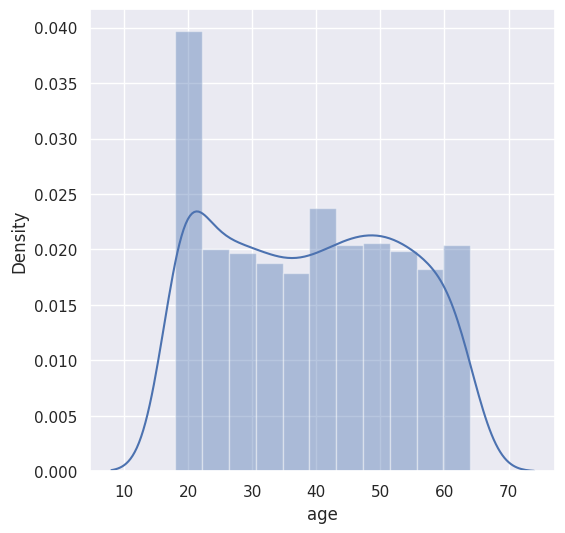

In [16]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(df['age'])
plt.show()

/tmp/ipykernel_2055/3920244418.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['bmi'])


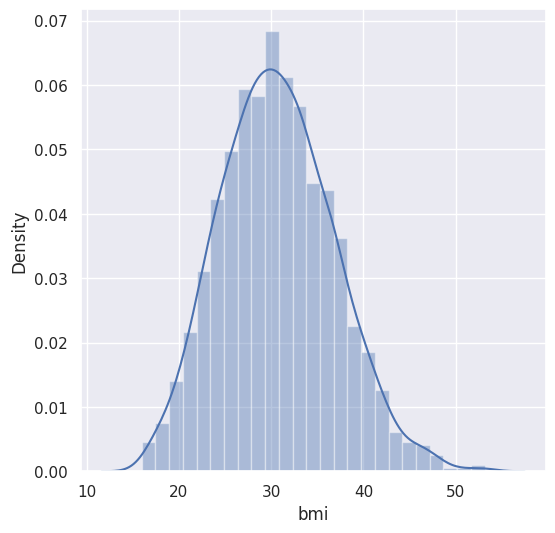

In [17]:
plt.figure(figsize=(6,6))
sns.distplot(df['bmi'])
plt.show()

/tmp/ipykernel_2055/25724184.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'])


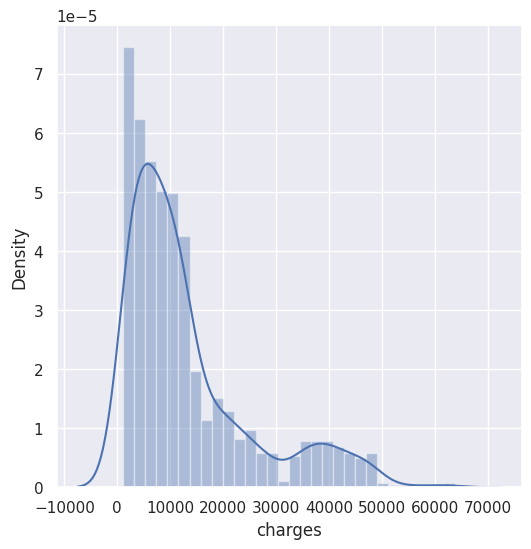

In [18]:
plt.figure(figsize=(6,6))
sns.distplot(df['charges'])
plt.show()

In [11]:
df.replace({"sex":{'male':0,'female':1}},inplace=True)
df.replace({"smoker":{"yes":1,"no":0}}, inplace=True)

/tmp/ipykernel_2055/789873606.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sex":{'male':0,'female':1}},inplace=True)
/tmp/ipykernel_2055/789873606.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"smoker":{"yes":1,"no":0}}, inplace=True)


In [21]:
df.replace({"region":{"southeast":0,"southwest":1, "northeast":2,"northwest":3}}, inplace=True)

/tmp/ipykernel_2055/144628503.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"region":{"southeast":0,"southwest":1, "northeast":2,"northwest":3}}, inplace=True)


In [22]:
df["region"].value_counts()

,count
region,
0,364
1,325
3,325
2,324


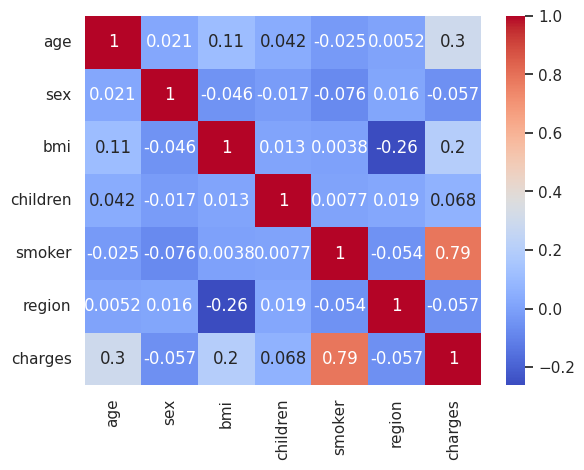

In [23]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [24]:
X = df.drop(columns='charges', axis=1)
Y = df['charges']

In [25]:
print(X)
print(Y)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       1       1
1      18    0  33.770         1       0       0
2      28    0  33.000         3       0       0
3      33    0  22.705         0       0       3
4      32    0  28.880         0       0       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       0       3
1334   18    1  31.920         0       0       2
1335   18    1  36.850         0       0       0
1336   21    1  25.800         0       0       1
1337   61    1  29.070         0       1       3

[1338 rows x 6 columns]
0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [27]:
print(X.shape, X_train.shape, X_test.shape)

(1338, 6) (1070, 6) (268, 6)


In [39]:
model = LinearRegression()

In [40]:
model.fit(X_train, Y_train)

LinearRegression()

In [42]:
train_pred = model.predict(X_train)
train_acc = metrics.r2_score(Y_train, train_pred)
print("Training Accuracy: ", train_acc)

Training Accuracy:  0.751505643411174


In [43]:
test_pred = model.predict(X_test)
test_acc = metrics.r2_score(Y_test, test_pred)
print("Testing Accuracy: ", test_acc)


Testing Accuracy:  0.7447273869684076


In [47]:
input_data = [18, 0,	33.770,	1,0,0]
input_data_as_numpy_array = np.asarray(input_data)
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)
prediction = model.predict(input_data_reshaped)
print(prediction)

[3701.06157802]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
